This notebook includes runs related to unmixing by using:

1. A very simple CNN, of various different channel sizes. These sizes for hidden channels, kernels, and modes are:
    - [8], [4, 4], [3, 3] 
    - [16, 16], [8, 8, 8], [3, 3, 3] 
    - [32, 32, 32], [16, 16, 16, 16], [3, 3, 3, 3] 
    - [64, 64, 64, 64], [32, 32, 32, 32, 32], [3, 3, 3, 3, 3] 
    - [128, 128, 128, 128, 128], [64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3] 
    - [256, 256, 256, 256, 256, 256], [64, 64, 64, 64, 64, 64, 64], [3, 3, 3, 3, 3, 3, 3] 
2. P, Q, final projection networks as follows:
    - For P:
        - in_ch=1
        - out_ch=128
        - hidden_ch=[8, 32]
    - For Q:
        - in_ch=128
        - out_ch=32
        - hidden_ch=[32, 8]
    - For final projection:
        - Linear[32, 64]
        - GELU
        - Linear[64, 3]
3. Of varying learning rates fine tuned for the given model. With a Cosine annealing lr scheduler with warmup in first 10 epochs.
4. With dropout, optimized using AdamW.
5. A loss of simple MSE, with a small additional terms for sum of residuals.
6. With a training loop that loops over the entire training dataset at each epoch, with a max epochs of 80.
7. Data separated into 1500 training samples, 100 static validation samples, and 123 static test samples.
8. Trained using a GPU.
9. Statistically normalized datasets.
10. GELU as the activation function throughout.

### Imports, data, model initialization, and various other setups

In [1]:
# Set up autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Sys Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[3]
sys.path.append(str(github_root))

In [3]:
# Self-def imports

from src.dl.data import get_data
from src.dl.models.fno.FNO import FNO_nD
from src.dl.train import train_model

In [4]:
# Package imports
import torch
import torch.nn as nn

In [5]:
# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# Data hyperparams
save_path = rf"{github_root}\data\simpler_data_rwc.csv"

batch_size = 32
epoch = 80
n_tb_epoch = 47

In [7]:
# Define model configs

cfg_p = {
    'in_channels': 1, 
    'out_channels': 128, 
    'hidden_channels': [8, 32], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}

cfg_q = {
    'in_channels': 128, 
    'out_channels': 32, 
    'hidden_channels': [128, 64], 
    'dropout': 0.05,
    'act_fn': 'gelu'
}



models_list = [
    {
        'fb_hidden_channels': [8], 'fb_modes': [[4], [4]], 'fb_kernel': [3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [16,16], 'fb_modes': [[8], [8], [8]], 'fb_kernel': [3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    },
    {
        'fb_hidden_channels': [32,32,32], 'fb_modes': [[16], [16], [16], [16]], 'fb_kernel': [3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [64,64,64,64], 'fb_modes': [[32], [32], [32], [32], [32]], 'fb_kernel': [3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [128,128,128,128,128], 'fb_modes': [[40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3], 'cfg_p': cfg_p, 'cfg_q': cfg_q 
    },
    {
        'fb_hidden_channels': [256,256,256,256,256,256], 'fb_modes': [[40], [40], [40], [40], [40], [40], [40]], 'fb_kernel': [3, 3, 3, 3, 3, 3,3], 'cfg_p': cfg_p, 'cfg_q': cfg_q
    }
]

lr_list = [1e-3, 2.5e-3, 5e-3, 8e-4, 3e-4, 3e-4]

dir_list = [
    'fno_8',
    'fno_16',
    'fno_32',
    'fno_64',
    'fno_128',
    'fno_256'
]

name_list = [
        'FNO_8',
        'FNO_16',
        'FNO_32',
        'FNO_64',
        'FNO_128',
        'FNO_256'
    ]

# Create dirs

for dir_name in dir_list:
    save_dir = github_root / 'runs' / 'dl' / 'simpler_data' / 'fno' / dir_name
    save_dir.mkdir(parents=True, exist_ok=True)

### Model train loop

Epoch 1/80, Step 1/47, Train Loss: 0.123640
Epoch 1/80, Step 2/47, Train Loss: 0.093394
Epoch 1/80, Step 3/47, Train Loss: 0.120197
Epoch 1/80, Step 4/47, Train Loss: 0.116796
Epoch 1/80, Step 5/47, Train Loss: 0.103594
Epoch 1/80, Step 6/47, Train Loss: 0.089654
Epoch 1/80, Step 7/47, Train Loss: 0.102991
Epoch 1/80, Step 8/47, Train Loss: 0.099634
Epoch 1/80, Step 9/47, Train Loss: 0.097124
Epoch 1/80, Step 10/47, Train Loss: 0.115962
Epoch 1/80, Step 11/47, Train Loss: 0.095957
Epoch 1/80, Step 12/47, Train Loss: 0.106705
Epoch 1/80, Step 13/47, Train Loss: 0.111310
Epoch 1/80, Step 14/47, Train Loss: 0.119150
Epoch 1/80, Step 15/47, Train Loss: 0.104038
Epoch 1/80, Step 16/47, Train Loss: 0.102284
Epoch 1/80, Step 17/47, Train Loss: 0.110297
Epoch 1/80, Step 18/47, Train Loss: 0.100582
Epoch 1/80, Step 19/47, Train Loss: 0.088680
Epoch 1/80, Step 20/47, Train Loss: 0.103076
Epoch 1/80, Step 21/47, Train Loss: 0.102848
Epoch 1/80, Step 22/47, Train Loss: 0.086645
Epoch 1/80, Step 23

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.038572
Epoch 11/80, Step 2/47, Train Loss: 0.025363
Epoch 11/80, Step 3/47, Train Loss: 0.024338
Epoch 11/80, Step 4/47, Train Loss: 0.038229
Epoch 11/80, Step 5/47, Train Loss: 0.017257
Epoch 11/80, Step 6/47, Train Loss: 0.029490
Epoch 11/80, Step 7/47, Train Loss: 0.046488
Epoch 11/80, Step 8/47, Train Loss: 0.017646
Epoch 11/80, Step 9/47, Train Loss: 0.020449
Epoch 11/80, Step 10/47, Train Loss: 0.035298
Epoch 11/80, Step 11/47, Train Loss: 0.038764
Epoch 11/80, Step 12/47, Train Loss: 0.024562
Epoch 11/80, Step 13/47, Train Loss: 0.020838
Epoch 11/80, Step 14/47, Train Loss: 0.045725
Epoch 11/80, Step 15/47, Train Loss: 0.040315
Epoch 11/80, Step 16/47, Train Loss: 0.032174
Epoch 11/80, Step 17/47, Train Loss: 0.022063
Epoch 11/80, Step 18/47, Train Loss: 0.019732
Epoch 11/80, Step 19/47, Train Loss: 0.034702
Epoch 11/80, Step 20/47, Train Loss: 0.019342
Epoch 11/80, Step 21/47, Train Loss: 0.034900
Epoch 11/80, Step 22/47, Train Loss: 0.0256

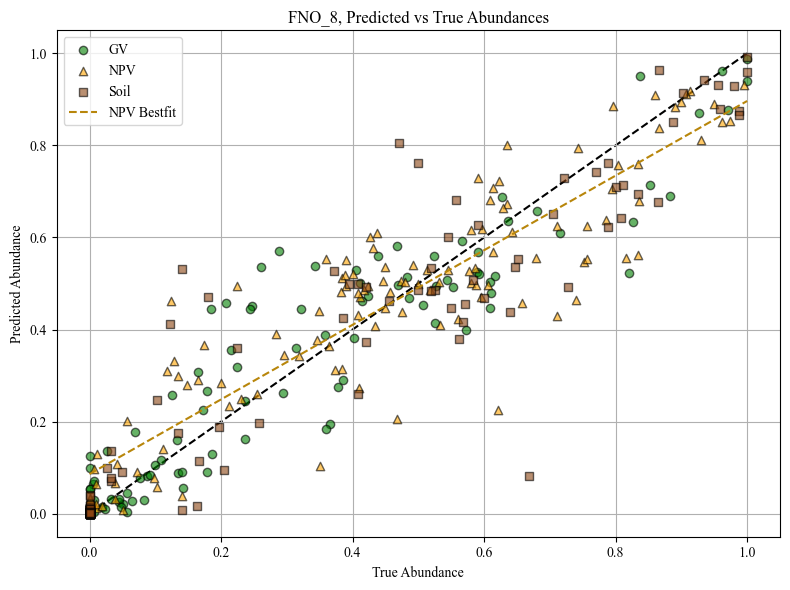

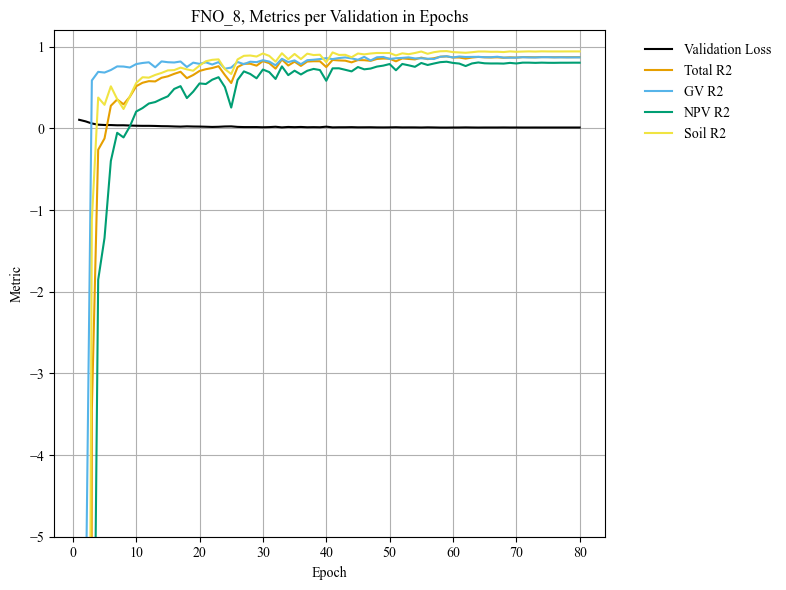

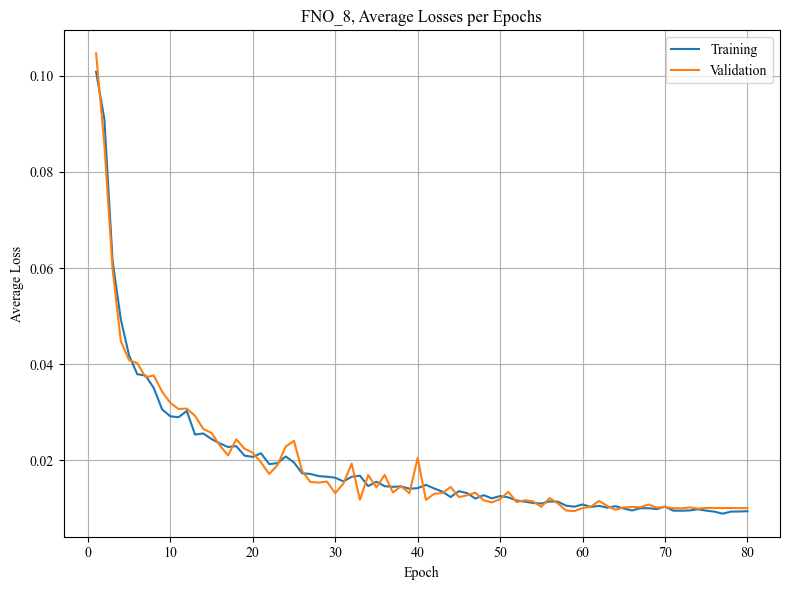

Testing complete
[[1.16539000e+05 1.68157440e+07 1.17710019e-02 8.45562160e-01
  8.77046943e-01 7.73890734e-01 8.85748684e-01 7.18901381e-02
  6.48804083e-02 9.00338739e-02 6.07561246e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.109457
Epoch 1/80, Step 2/47, Train Loss: 0.098568
Epoch 1/80, Step 3/47, Train Loss: 0.109890
Epoch 1/80, Step 4/47, Train Loss: 0.102368
Epoch 1/80, Step 5/47, Train Loss: 0.100869
Epoch 1/80, Step 6/47, Train Loss: 0.116496
Epoch 1/80, Step 7/47, Train Loss: 0.108252
Epoch 1/80, Step 8/47, Train Loss: 0.108191
Epoch 1/80, Step 9/47, Train Loss: 0.098881
Epoch 1/80, Step 10/47, Train Loss: 0.091957
Epoch 1/80, Step 11/47, Train Loss: 0.105358
Epoch 1/80, Step 12/47, Train Loss: 0.104900
Epoch 1/80, Step 13/47, Train Loss: 0.090832
Epoch 1/80, Step 14/47, Train Loss: 0.094845
Epoch 1/80, Step 15/47, Train Loss: 0.097447
Epoch 1/80, Step 16/47, Train Loss: 0.090470
Epoch 1/80, Step 17/47, Train Loss: 0.094303
Epoch 1/80, Step 18/47, Train Loss: 0.100001
Epoch 1/8

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.023922
Epoch 11/80, Step 2/47, Train Loss: 0.043188
Epoch 11/80, Step 3/47, Train Loss: 0.044525
Epoch 11/80, Step 4/47, Train Loss: 0.020684
Epoch 11/80, Step 5/47, Train Loss: 0.025751
Epoch 11/80, Step 6/47, Train Loss: 0.026558
Epoch 11/80, Step 7/47, Train Loss: 0.028308
Epoch 11/80, Step 8/47, Train Loss: 0.041216
Epoch 11/80, Step 9/47, Train Loss: 0.032613
Epoch 11/80, Step 10/47, Train Loss: 0.029060
Epoch 11/80, Step 11/47, Train Loss: 0.025759
Epoch 11/80, Step 12/47, Train Loss: 0.032712
Epoch 11/80, Step 13/47, Train Loss: 0.024902
Epoch 11/80, Step 14/47, Train Loss: 0.016974
Epoch 11/80, Step 15/47, Train Loss: 0.017018
Epoch 11/80, Step 16/47, Train Loss: 0.024691
Epoch 11/80, Step 17/47, Train Loss: 0.018403
Epoch 11/80, Step 18/47, Train Loss: 0.016202
Epoch 11/80, Step 19/47, Train Loss: 0.018618
Epoch 11/80, Step 20/47, Train Loss: 0.022218
Epoch 11/80, Step 21/47, Train Loss: 0.021272
Epoch 11/80, Step 22/47, Train Loss: 0.0163

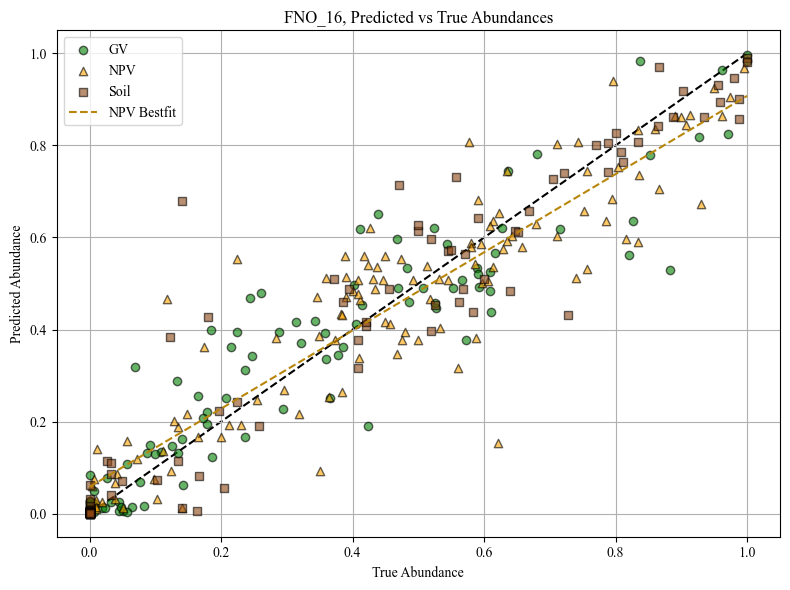

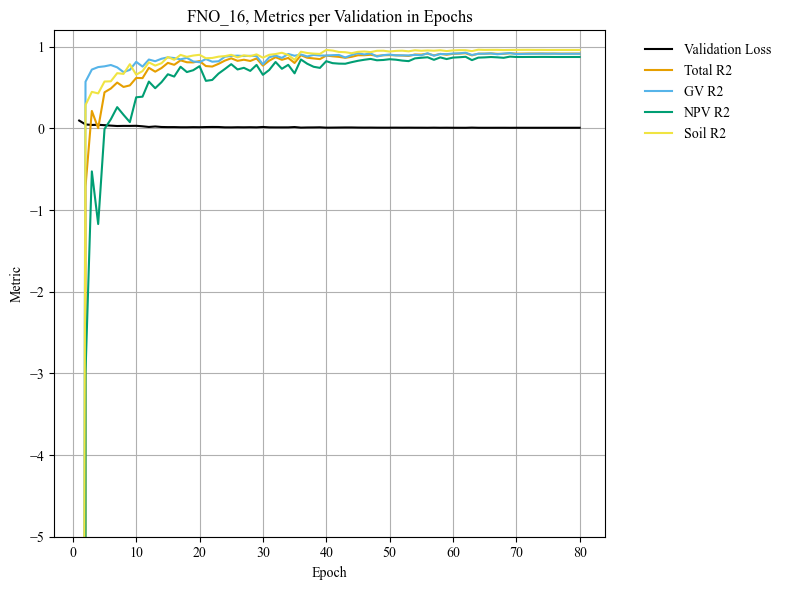

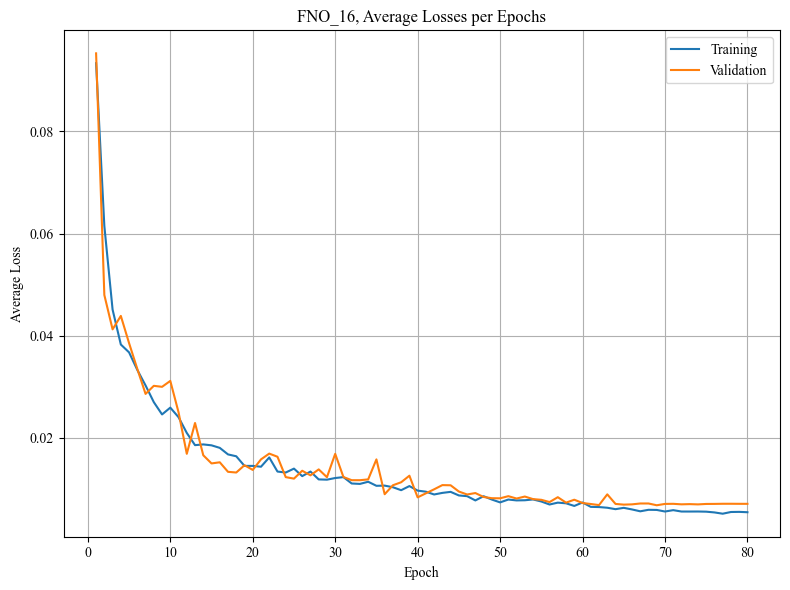

Testing complete
[[1.54019000e+05 1.85893120e+07 9.79888253e-03 8.74987900e-01
  8.84848535e-01 8.06461513e-01 9.33653831e-01 6.36309460e-02
  6.16016313e-02 8.39273408e-02 4.53638807e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.093240
Epoch 1/80, Step 2/47, Train Loss: 0.117558
Epoch 1/80, Step 3/47, Train Loss: 0.105788
Epoch 1/80, Step 4/47, Train Loss: 0.091242
Epoch 1/80, Step 5/47, Train Loss: 0.108261
Epoch 1/80, Step 6/47, Train Loss: 0.106034
Epoch 1/80, Step 7/47, Train Loss: 0.102179
Epoch 1/80, Step 8/47, Train Loss: 0.096894
Epoch 1/80, Step 9/47, Train Loss: 0.093093
Epoch 1/80, Step 10/47, Train Loss: 0.100562
Epoch 1/80, Step 11/47, Train Loss: 0.095336
Epoch 1/80, Step 12/47, Train Loss: 0.091804
Epoch 1/80, Step 13/47, Train Loss: 0.095084
Epoch 1/80, Step 14/47, Train Loss: 0.095199
Epoch 1/80, Step 15/47, Train Loss: 0.086518
Epoch 1/80, Step 16/47, Train Loss: 0.092144
Epoch 1/80, Step 17/47, Train Loss: 0.113962
Epoch 1/80, Step 18/47, Train Loss: 0.084728
Epoch 1/8

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 2/47, Train Loss: 0.014785
Epoch 11/80, Step 3/47, Train Loss: 0.016197
Epoch 11/80, Step 4/47, Train Loss: 0.016578
Epoch 11/80, Step 5/47, Train Loss: 0.024010
Epoch 11/80, Step 6/47, Train Loss: 0.024336
Epoch 11/80, Step 7/47, Train Loss: 0.021375
Epoch 11/80, Step 8/47, Train Loss: 0.020255
Epoch 11/80, Step 9/47, Train Loss: 0.014567
Epoch 11/80, Step 10/47, Train Loss: 0.011681
Epoch 11/80, Step 11/47, Train Loss: 0.019679
Epoch 11/80, Step 12/47, Train Loss: 0.021447
Epoch 11/80, Step 13/47, Train Loss: 0.020057
Epoch 11/80, Step 14/47, Train Loss: 0.026764
Epoch 11/80, Step 15/47, Train Loss: 0.038335
Epoch 11/80, Step 16/47, Train Loss: 0.013387
Epoch 11/80, Step 17/47, Train Loss: 0.016194
Epoch 11/80, Step 18/47, Train Loss: 0.013544
Epoch 11/80, Step 19/47, Train Loss: 0.017548
Epoch 11/80, Step 20/47, Train Loss: 0.020710
Epoch 11/80, Step 21/47, Train Loss: 0.020571
Epoch 11/80, Step 22/47, Train Loss: 0.017538
Epoch 11/80, Step 23/47, Train Loss: 0.022

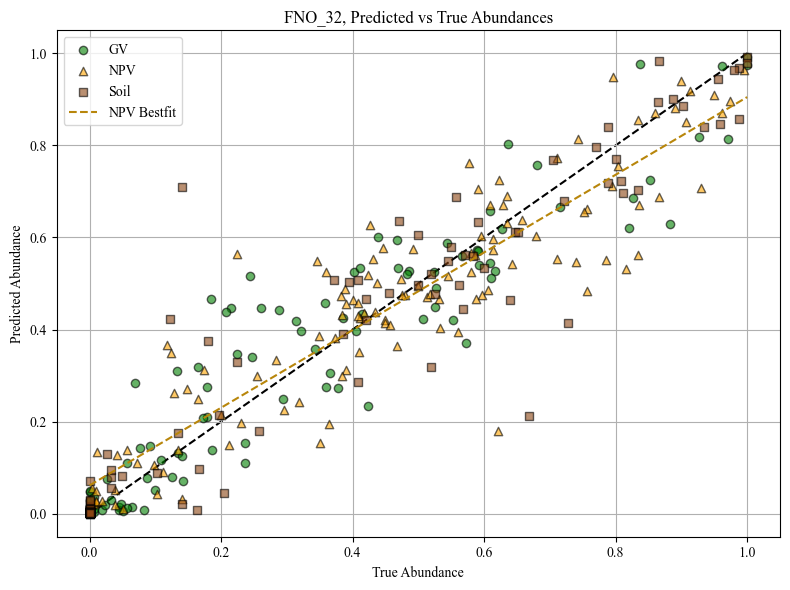

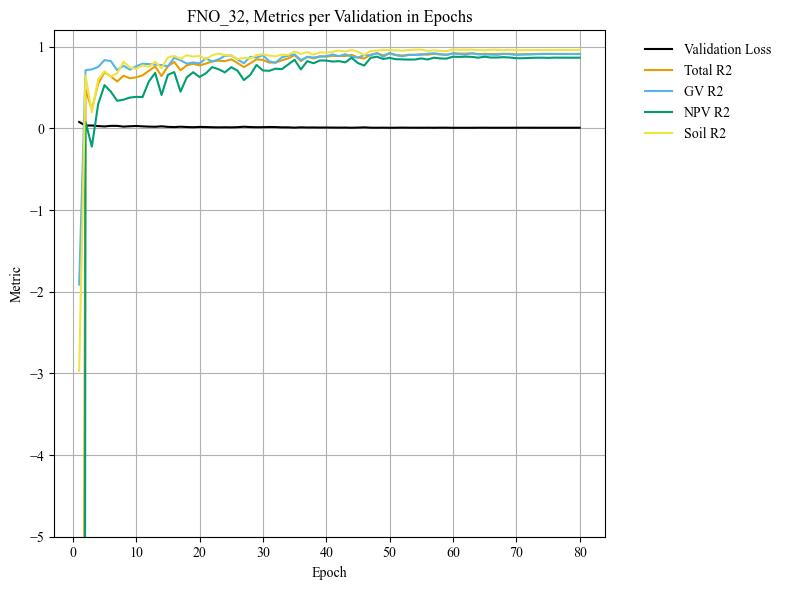

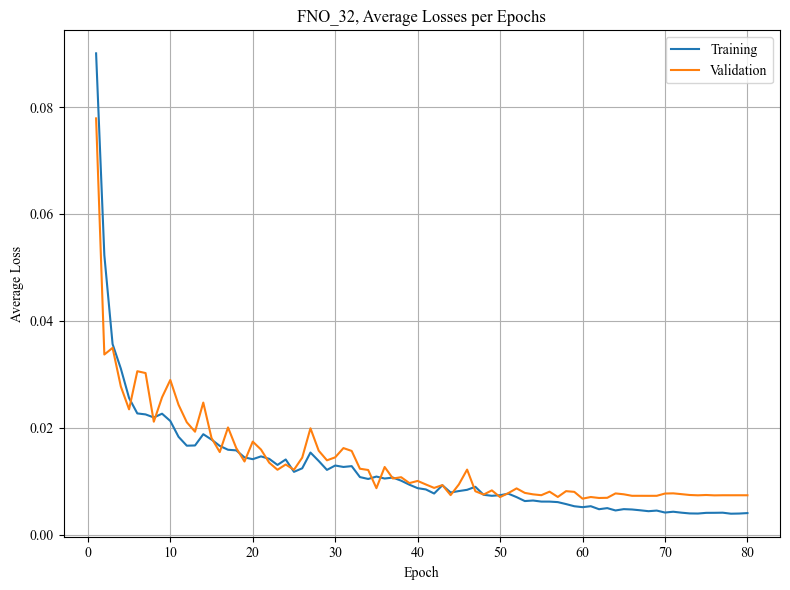

Testing complete
[[3.15315000e+05 2.39673600e+07 1.03013990e-02 8.70976508e-01
  8.91046226e-01 8.09941053e-01 9.11942184e-01 6.47574142e-02
  6.24369979e-02 8.16480219e-02 5.01872227e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.110682
Epoch 1/80, Step 2/47, Train Loss: 0.094439
Epoch 1/80, Step 3/47, Train Loss: 0.101524
Epoch 1/80, Step 4/47, Train Loss: 0.106748
Epoch 1/80, Step 5/47, Train Loss: 0.094138
Epoch 1/80, Step 6/47, Train Loss: 0.093001
Epoch 1/80, Step 7/47, Train Loss: 0.088818
Epoch 1/80, Step 8/47, Train Loss: 0.114347
Epoch 1/80, Step 9/47, Train Loss: 0.097849
Epoch 1/80, Step 10/47, Train Loss: 0.090052
Epoch 1/80, Step 11/47, Train Loss: 0.103455
Epoch 1/80, Step 12/47, Train Loss: 0.099110
Epoch 1/80, Step 13/47, Train Loss: 0.087292
Epoch 1/80, Step 14/47, Train Loss: 0.100925
Epoch 1/80, Step 15/47, Train Loss: 0.096482
Epoch 1/80, Step 16/47, Train Loss: 0.100988
Epoch 1/80, Step 17/47, Train Loss: 0.104845
Epoch 1/80, Step 18/47, Train Loss: 0.091535
Epoch 1/8

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.016876
Epoch 11/80, Step 2/47, Train Loss: 0.024679
Epoch 11/80, Step 3/47, Train Loss: 0.017985
Epoch 11/80, Step 4/47, Train Loss: 0.019102
Epoch 11/80, Step 5/47, Train Loss: 0.030322
Epoch 11/80, Step 6/47, Train Loss: 0.013020
Epoch 11/80, Step 7/47, Train Loss: 0.019269
Epoch 11/80, Step 8/47, Train Loss: 0.020500
Epoch 11/80, Step 9/47, Train Loss: 0.015470
Epoch 11/80, Step 10/47, Train Loss: 0.018855
Epoch 11/80, Step 11/47, Train Loss: 0.015375
Epoch 11/80, Step 12/47, Train Loss: 0.021686
Epoch 11/80, Step 13/47, Train Loss: 0.020569
Epoch 11/80, Step 14/47, Train Loss: 0.013369
Epoch 11/80, Step 15/47, Train Loss: 0.012836
Epoch 11/80, Step 16/47, Train Loss: 0.010584
Epoch 11/80, Step 17/47, Train Loss: 0.018702
Epoch 11/80, Step 18/47, Train Loss: 0.013892
Epoch 11/80, Step 19/47, Train Loss: 0.027153
Epoch 11/80, Step 20/47, Train Loss: 0.034851
Epoch 11/80, Step 21/47, Train Loss: 0.014895
Epoch 11/80, Step 22/47, Train Loss: 0.0261

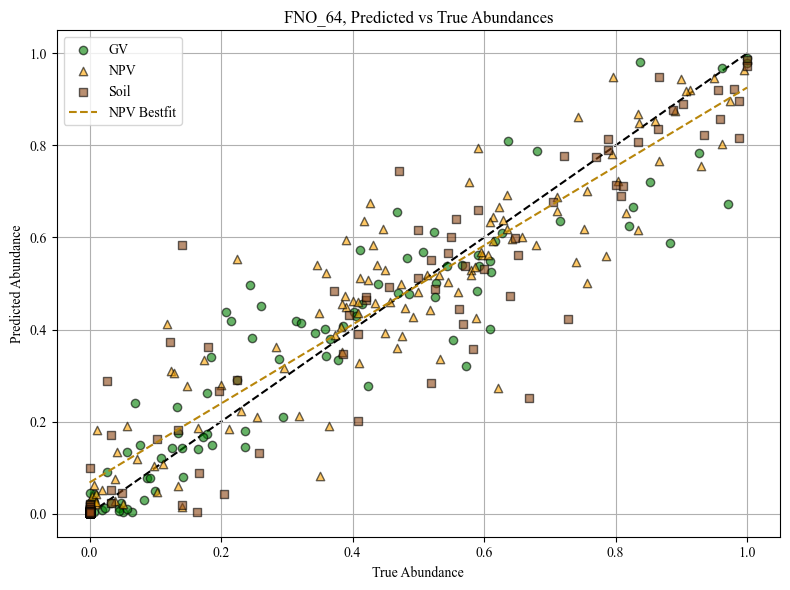

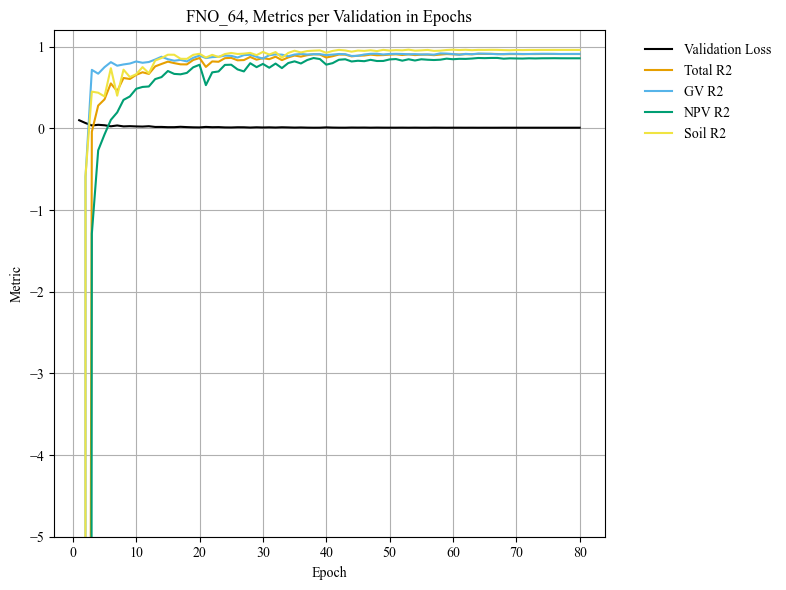

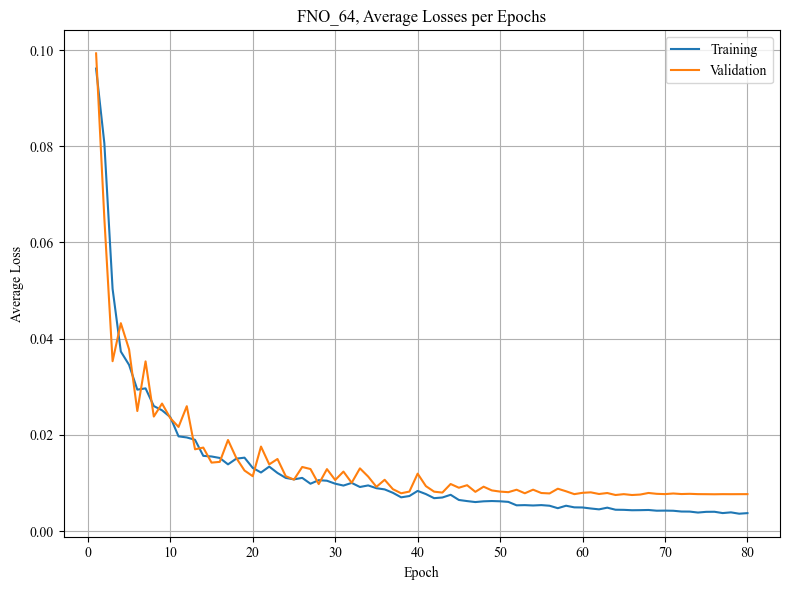

Testing complete
[[1.18638700e+06 4.41524480e+07 1.03131747e-02 8.70704174e-01
  8.89662504e-01 8.16991389e-01 9.05458570e-01 6.57172352e-02
  5.88095784e-02 8.28159451e-02 5.55261858e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.089114
Epoch 1/80, Step 2/47, Train Loss: 0.101314
Epoch 1/80, Step 3/47, Train Loss: 0.120917
Epoch 1/80, Step 4/47, Train Loss: 0.120258
Epoch 1/80, Step 5/47, Train Loss: 0.077979
Epoch 1/80, Step 6/47, Train Loss: 0.094402
Epoch 1/80, Step 7/47, Train Loss: 0.120692
Epoch 1/80, Step 8/47, Train Loss: 0.099754
Epoch 1/80, Step 9/47, Train Loss: 0.130928
Epoch 1/80, Step 10/47, Train Loss: 0.106768
Epoch 1/80, Step 11/47, Train Loss: 0.109414
Epoch 1/80, Step 12/47, Train Loss: 0.093849
Epoch 1/80, Step 13/47, Train Loss: 0.078000
Epoch 1/80, Step 14/47, Train Loss: 0.092708
Epoch 1/80, Step 15/47, Train Loss: 0.102867
Epoch 1/80, Step 16/47, Train Loss: 0.098696
Epoch 1/80, Step 17/47, Train Loss: 0.089562
Epoch 1/80, Step 18/47, Train Loss: 0.109183
Epoch 1/8

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 11/80, Step 1/47, Train Loss: 0.020905
Epoch 11/80, Step 2/47, Train Loss: 0.027444
Epoch 11/80, Step 3/47, Train Loss: 0.016228
Epoch 11/80, Step 4/47, Train Loss: 0.021828
Epoch 11/80, Step 5/47, Train Loss: 0.017881
Epoch 11/80, Step 6/47, Train Loss: 0.020873
Epoch 11/80, Step 7/47, Train Loss: 0.023127
Epoch 11/80, Step 8/47, Train Loss: 0.022418
Epoch 11/80, Step 9/47, Train Loss: 0.015230
Epoch 11/80, Step 10/47, Train Loss: 0.021306
Epoch 11/80, Step 11/47, Train Loss: 0.017141
Epoch 11/80, Step 12/47, Train Loss: 0.023410
Epoch 11/80, Step 13/47, Train Loss: 0.018329
Epoch 11/80, Step 14/47, Train Loss: 0.021515
Epoch 11/80, Step 15/47, Train Loss: 0.020707
Epoch 11/80, Step 16/47, Train Loss: 0.022253
Epoch 11/80, Step 17/47, Train Loss: 0.017966
Epoch 11/80, Step 18/47, Train Loss: 0.022890
Epoch 11/80, Step 19/47, Train Loss: 0.014023
Epoch 11/80, Step 20/47, Train Loss: 0.019126
Epoch 11/80, Step 21/47, Train Loss: 0.010969
Epoch 11/80, Step 22/47, Train Loss: 0.0135

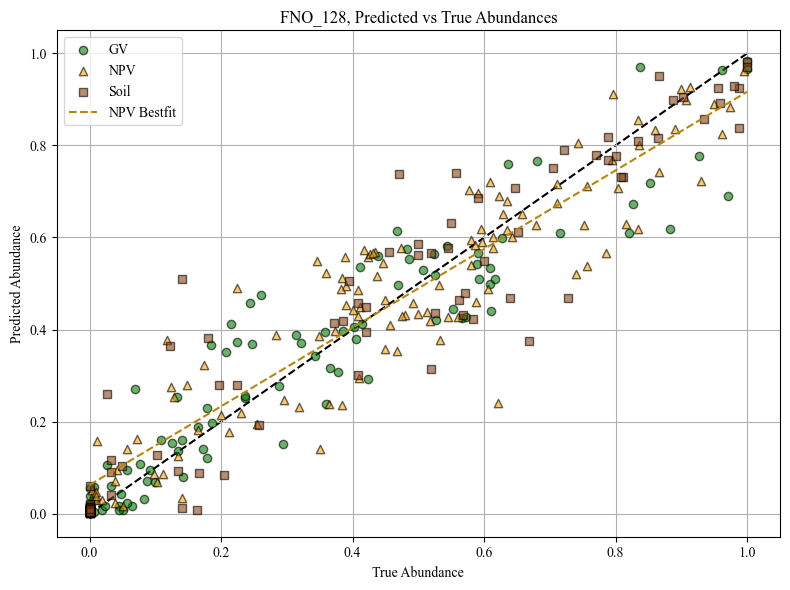

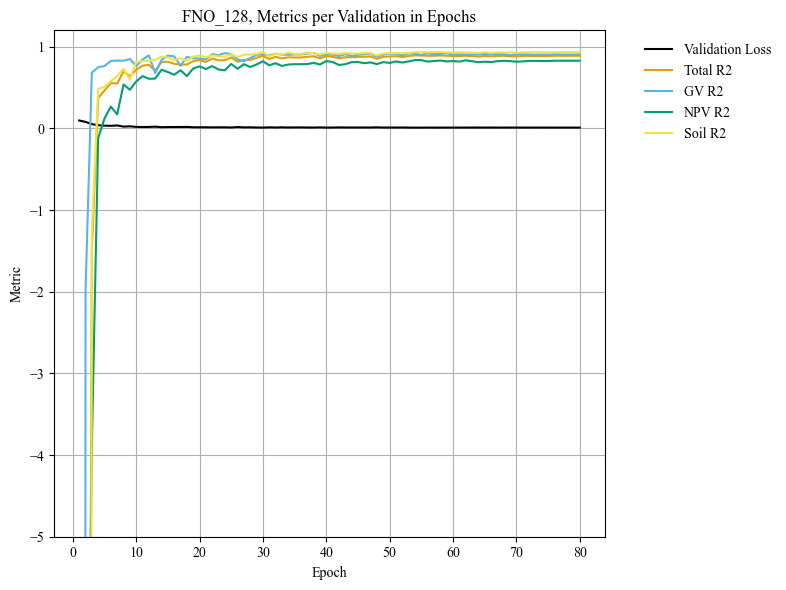

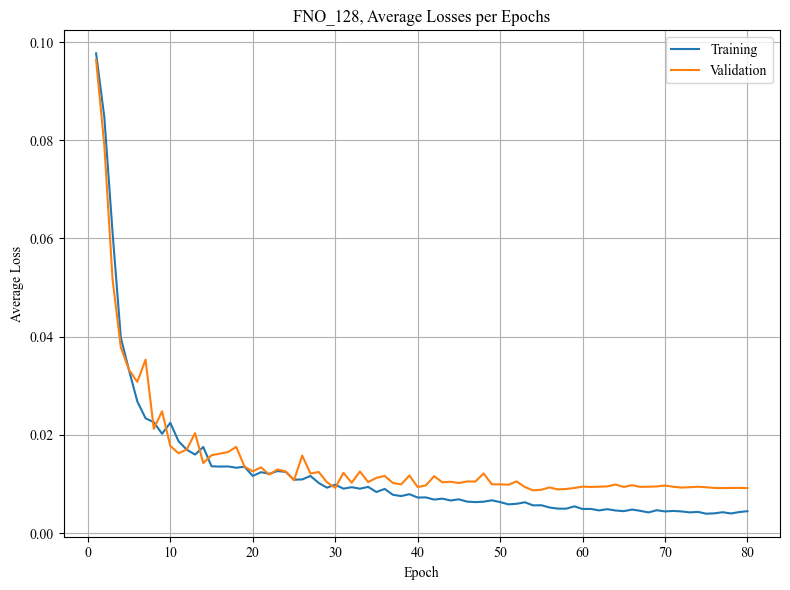

Testing complete
[[4.65704300e+06 1.22926720e+08 8.73724185e-03 8.86998653e-01
  8.96347344e-01 8.34136009e-01 9.30512667e-01 6.36367798e-02
  5.76051064e-02 8.08985308e-02 5.24066910e-02]]
Epoch 1/80, Step 1/47, Train Loss: 0.099008
Epoch 1/80, Step 2/47, Train Loss: 0.103003
Epoch 1/80, Step 3/47, Train Loss: 0.089576
Epoch 1/80, Step 4/47, Train Loss: 0.087510
Epoch 1/80, Step 5/47, Train Loss: 0.092327
Epoch 1/80, Step 6/47, Train Loss: 0.088253
Epoch 1/80, Step 7/47, Train Loss: 0.103096
Epoch 1/80, Step 8/47, Train Loss: 0.109696
Epoch 1/80, Step 9/47, Train Loss: 0.104240
Epoch 1/80, Step 10/47, Train Loss: 0.095348
Epoch 1/80, Step 11/47, Train Loss: 0.095536
Epoch 1/80, Step 12/47, Train Loss: 0.107127
Epoch 1/80, Step 13/47, Train Loss: 0.101430
Epoch 1/80, Step 14/47, Train Loss: 0.094573
Epoch 1/80, Step 15/47, Train Loss: 0.093600
Epoch 1/80, Step 16/47, Train Loss: 0.109456
Epoch 1/80, Step 17/47, Train Loss: 0.093453
Epoch 1/80, Step 18/47, Train Loss: 0.111079
Epoch 1/8

c:\Users\Ege Artan\.code\Python\Python_311_Main\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 10/80, Step 47/47, Train Loss: 0.018582
Epoch 10/80 complete. Train Loss: 0.020379, Val Loss: 0.018946
Epoch 11/80, Step 1/47, Train Loss: 0.018983
Epoch 11/80, Step 2/47, Train Loss: 0.020755
Epoch 11/80, Step 3/47, Train Loss: 0.020186
Epoch 11/80, Step 4/47, Train Loss: 0.014264
Epoch 11/80, Step 5/47, Train Loss: 0.018444
Epoch 11/80, Step 6/47, Train Loss: 0.008825
Epoch 11/80, Step 7/47, Train Loss: 0.016176
Epoch 11/80, Step 8/47, Train Loss: 0.015488
Epoch 11/80, Step 9/47, Train Loss: 0.012745
Epoch 11/80, Step 10/47, Train Loss: 0.016249
Epoch 11/80, Step 11/47, Train Loss: 0.013621
Epoch 11/80, Step 12/47, Train Loss: 0.024214
Epoch 11/80, Step 13/47, Train Loss: 0.011542
Epoch 11/80, Step 14/47, Train Loss: 0.016681
Epoch 11/80, Step 15/47, Train Loss: 0.021577
Epoch 11/80, Step 16/47, Train Loss: 0.013462
Epoch 11/80, Step 17/47, Train Loss: 0.024167
Epoch 11/80, Step 18/47, Train Loss: 0.020377
Epoch 11/80, Step 19/47, Train Loss: 0.020998
Epoch 11/80, Step 20/47, T

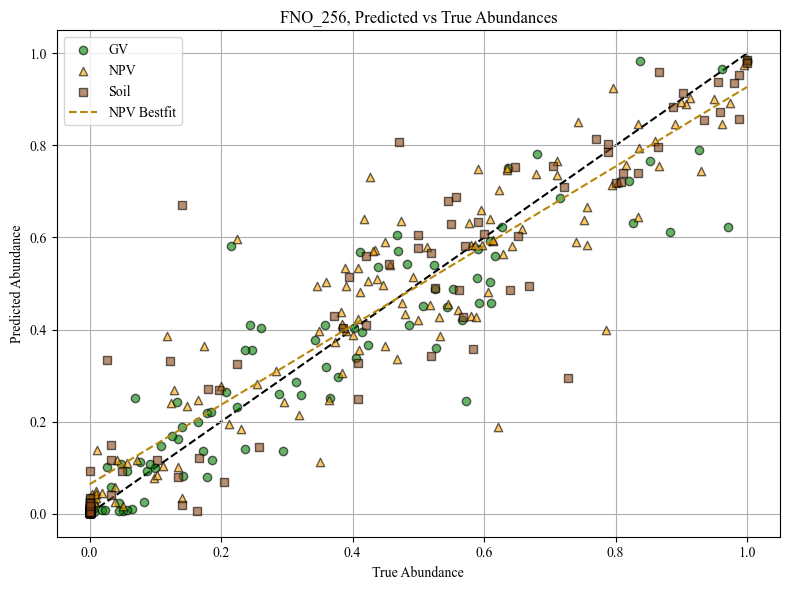

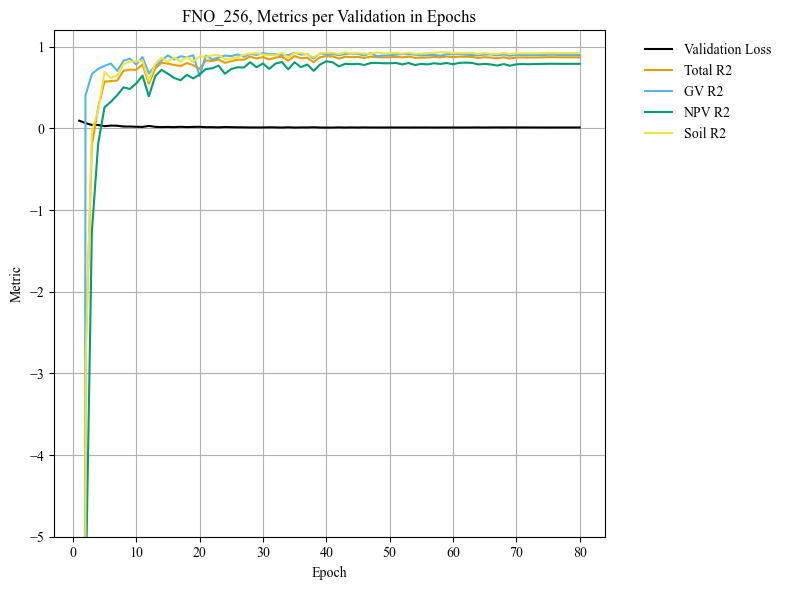

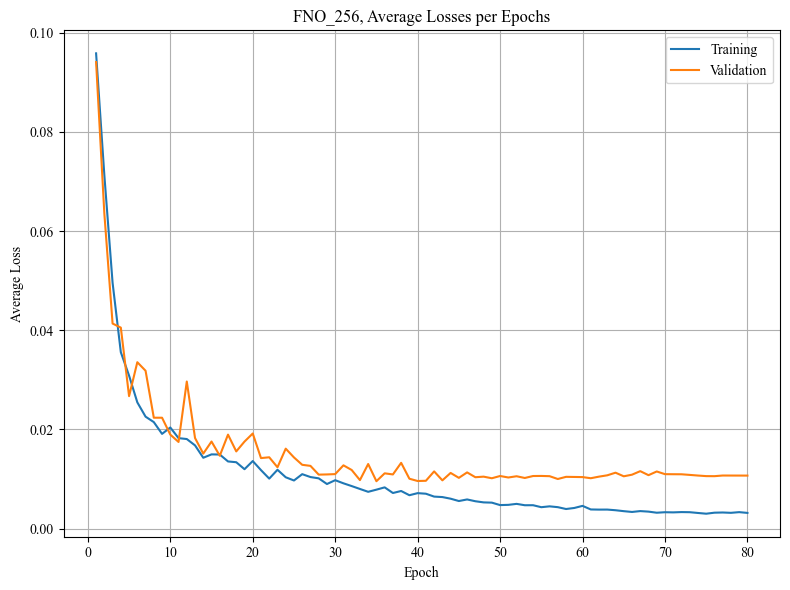

Testing complete
[[1.86529470e+07 4.97792640e+08 1.05058420e-02 8.69745731e-01
  8.85154247e-01 8.15401137e-01 9.08681929e-01 6.62117526e-02
  5.81341200e-02 8.37486535e-02 5.67524880e-02]]


In [8]:
fno_dict = {}
import gc


for i in range(len(models_list)):
    
    cfg_dict = models_list[i]
    lr = lr_list[i]
    save_dir = dir_list[i]
    model_name = name_list[i]

    dataloaders = get_data(save_path=save_path, spec_range=[900, 1690], batch_size=32)
    model = FNO_nD(**cfg_dict).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    warmup_epochs = 10 
    total_steps = epoch * n_tb_epoch
    warmup_steps = warmup_epochs * n_tb_epoch
    # warmup
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, 
        start_factor=0.1, 
        total_iters=warmup_steps
    )
    # cosine annealing
    main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=total_steps - warmup_steps, 
        eta_min=1e-6
    )
    # combination
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, main_scheduler],
        milestones=[warmup_steps]
    )

    loss = nn.MSELoss()

    model_dict = train_model(
        model=model,
        loss_fn=loss,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        configured_data=dataloaders,
        n_epoch=epoch,
        n_tb_epoch=n_tb_epoch,
        device=device,
        dtype=torch.float32,
        save_dir=save_dir,
        model_name=model_name
    )

    # After training a model and saving it to the dict/disk
    del model 
    gc.collect()
    torch.cuda.empty_cache()

    fno_dict[model_name] = model_dict
    print(fno_dict[model_name]['metrics_total'])

In [9]:
import pickle
with open('fno_dict.pkl', 'wb') as fp:
    pickle.dump(fno_dict, fp)

In [10]:
# Best models
best_models = [64,128,256]

for i in best_models:
    key = f'FNO_{i}'
    print(f'{key}, {fno_dict[key]["metrics_total"]}')


FNO_64, [[1.18638700e+06 4.41524480e+07 1.03131747e-02 8.70704174e-01
  8.89662504e-01 8.16991389e-01 9.05458570e-01 6.57172352e-02
  5.88095784e-02 8.28159451e-02 5.55261858e-02]]
FNO_128, [[4.65704300e+06 1.22926720e+08 8.73724185e-03 8.86998653e-01
  8.96347344e-01 8.34136009e-01 9.30512667e-01 6.36367798e-02
  5.76051064e-02 8.08985308e-02 5.24066910e-02]]
FNO_256, [[1.86529470e+07 4.97792640e+08 1.05058420e-02 8.69745731e-01
  8.85154247e-01 8.15401137e-01 9.08681929e-01 6.62117526e-02
  5.81341200e-02 8.37486535e-02 5.67524880e-02]]


In [15]:
for i in fno_dict.keys():
    print(f"For {i}, NPV R2: {fno_dict[i]['metrics_total'][0][5]}, param#: {fno_dict[i]['metrics_total'][0][0]}")

For FNO_8, NPV R2: 0.7738907337188721, param#: 116539.0
For FNO_16, NPV R2: 0.80646151304245, param#: 154019.0
For FNO_32, NPV R2: 0.8099410533905029, param#: 315315.0
For FNO_64, NPV R2: 0.81699138879776, param#: 1186387.0
For FNO_128, NPV R2: 0.8341360092163086, param#: 4657043.0
For FNO_256, NPV R2: 0.8154011368751526, param#: 18652947.0
